<a href="https://colab.research.google.com/github/ponaalagar/tranfer_learning/blob/main/Audio_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub librosa tensorflow tensorflow_hub resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.8 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import librosa
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models

In [ ]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("chrisfilo/urbansound8k")
print("Dataset path:", path)

# Load metadata
metadata_path = os.path.join(path, "UrbanSound8K.csv")
metadata = pd.read_csv(metadata_path)

# Take only 100 samples per class (IMPORTANT)
metadata = metadata.groupby('class').head(100)

100%|██████████| 5.61G/5.61G [01:11<00:00, 84.3MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1


In [ ]:
# Load YAMNet model (Transfer Learning)
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Feature extraction function
def extract_embedding(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        scores, embeddings, spectrogram = yamnet_model(audio)
        embedding = np.mean(embeddings.numpy(), axis=0)
        return embedding
    except:
        return None

# Prepare dataset
X = []
y = []

for index, row in metadata.iterrows():
    file_name = row['slice_file_name']
    fold = row['fold']
    label = row['class']

    file_path = os.path.join(path, f"fold{fold}", file_name)

    embedding = extract_embedding(file_path)

    if embedding is not None:
        X.append(embedding)
        y.append(label)

# Convert to numpy
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

Feature shape: (1000, 1024)


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build model
model = models.Sequential([
    layers.Input(shape=(1024,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(set(y)), activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6050 - loss: 1.4284 - val_accuracy: 0.9100 - val_loss: 0.6955
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8575 - loss: 0.6151 - val_accuracy: 0.9400 - val_loss: 0.3799
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8838 - loss: 0.4416 - val_accuracy: 0.9500 - val_loss: 0.2857
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9262 - loss: 0.3359 - val_accuracy: 0.9450 - val_loss: 0.2349
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9237 - loss: 0.2872 - val_accuracy: 0.9450 - val_loss: 0.2143
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9325 - loss: 0.2425 - val_accuracy: 0.9500 - val_loss: 0.1936
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9538 - loss: 0.1992 - val_accuracy: 0.9500 - val_loss: 0.1831
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9463 - loss: 0.1891 - val_accuracy: 0.9500 - v

In [ ]:
loss, acc = model.evaluate(X_train, y_train)

print("Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9812 - loss: 0.0999
Accuracy: 0.981249988079071


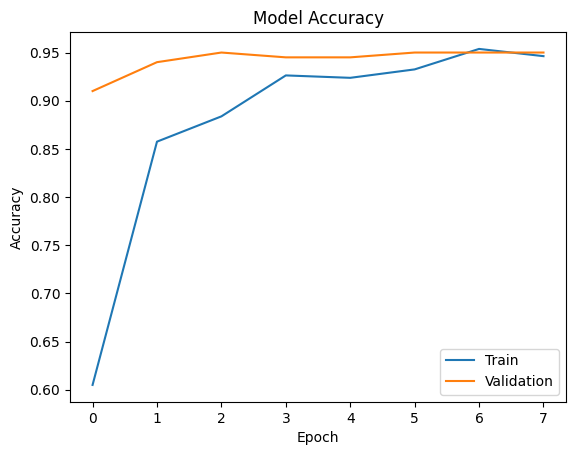

In [ ]:
# Plot accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
def predict_audio(file_path, actual_class):
    audio, sr = librosa.load(file_path, sr=16000)

    scores, embeddings, _ = yamnet_model(audio)
    embedding = np.mean(embeddings.numpy(), axis=0)
    embedding = embedding.reshape(1, -1)

    prediction = model.predict(embedding)
    predicted_label = np.argmax(prediction)
    class_name = le.inverse_transform([predicted_label])

    print("Actual Class   :", actual_class)
    print("Predicted Class:", class_name[0])

# Example prediction (change path if needed)
sample_row = metadata.sample(1).iloc[0]
sample_path = os.path.join(
    path,
    f"fold{sample_row['fold']}",
    sample_row['slice_file_name']
)

predict_audio(sample_path, sample_row['class'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Actual Class   : car_horn
Predicted Class: car_horn
